# Task 1: Exploring and Visualizing the Iris Dataset

## Problem Statement
The goal of this task is to explore the Iris dataset using pandas and create
visualizations to understand feature distributions and relationships between
the three flower species: Setosa, Versicolor, and Virginica.

## Goal
- Inspect the dataset structure and summary statistics
- Identify patterns and differences between species through plots

In [5]:
## Dataset Loading and Preprocessing

In [8]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('iris')

print("LOADING THE DATASET")
print("\n.shape")
print(df.shape)
print("\n.columns")
print(df.columns.tolist())
print("\n.head()")
print(df.head())

print("INSPECTION")
print("\n.info()")
df.info()
print("\n.describe()")
print(df.describe().round(2))
print("\nSpecies counts")
print(df['species'].value_counts())

LOADING THE DATASET

.shape
(150, 5)

.columns
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

.head()
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
INSPECTION

.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

.describ

In [ ]:
## Data Visualization and Exploration

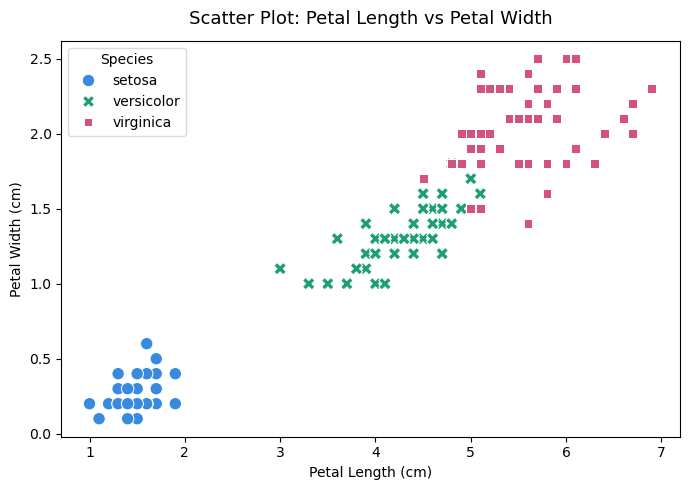


Saved scatter.png


In [9]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
labels   = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']
palette  = ['#378ADD', '#1D9E75', '#D4537E']
import matplotlib.pyplot as plt
# Scatter Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df, x='petal_length', y='petal_width',
    hue='species', style='species',
    palette=palette, s=80, ax=ax
)
ax.set_title('Scatter Plot: Petal Length vs Petal Width', fontsize=13, pad=12)
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.legend(title='Species', framealpha=0.7)
plt.tight_layout()
plt.show()
plt.close()
print("\nSaved scatter.png")
 

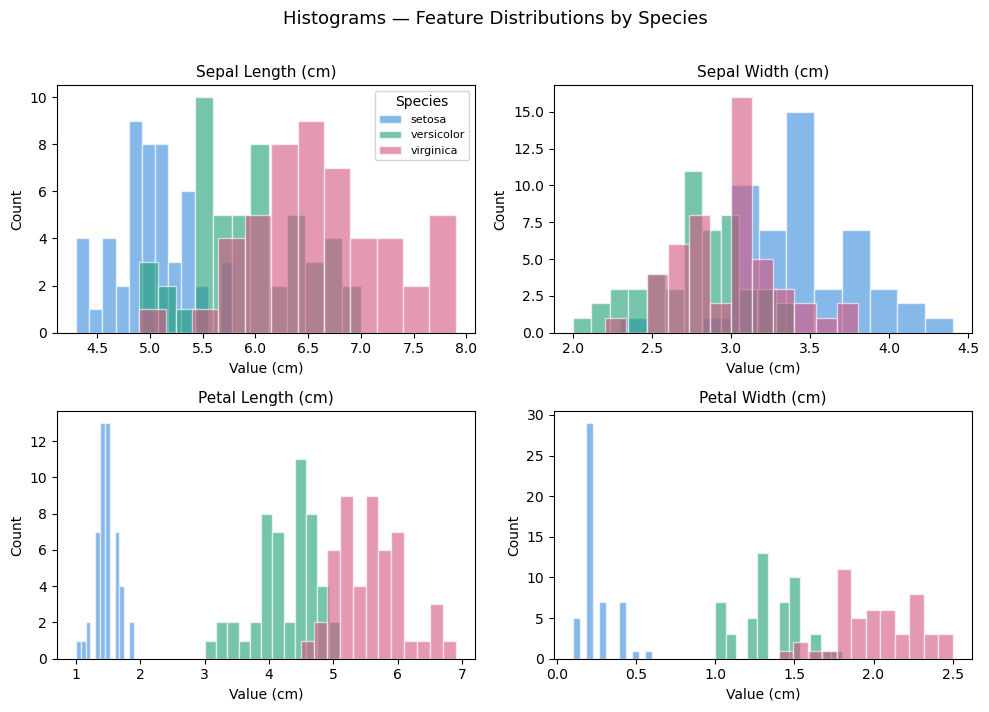

Saved histograms.png


In [10]:
#Histograms
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    for sp, color in zip(df['species'].unique(), palette):
        axes[i].hist(
            df[df['species'] == sp][feat],
            bins=12, alpha=0.6, color=color, label=sp, edgecolor='white'
        )
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel('Value (cm)')
    axes[i].set_ylabel('Count')
    if i == 0:
        axes[i].legend(title='Species', fontsize=8)
 
fig.suptitle('Histograms — Feature Distributions by Species', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
plt.close()
print("Saved histograms.png")
 


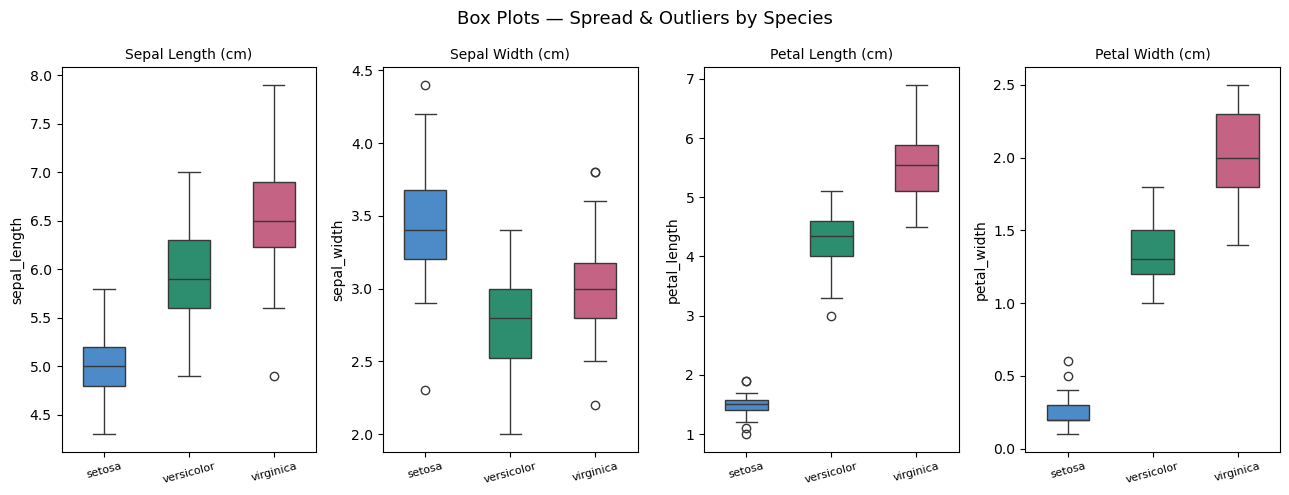

In [12]:
#Box Plots 
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(13,5))
for i, (feat, label) in enumerate(zip(features, labels)):
    sns.boxplot(data=df, x='species', y=feat, hue='species',
                palette=['#378ADD','#1D9E75','#D4537E'], width=0.5, legend=False, ax=axes[i])
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15, labelsize=8)
fig.suptitle('Box Plots — Spread & Outliers by Species', fontsize=13)
plt.tight_layout()
plt.show()

## Explanation of Results and Final Insights

### Scatter Plot
- **Setosa** is completely isolated from the other two species based on petal size alone.
- **Versicolor** and **Virginica** slightly overlap, making them harder to separate.

### Histograms
- **Petal length** is bimodal — Setosa sits at 1–2 cm, others at 3–7 cm.
- **Sepal width** is the most normally distributed and least useful for separating species.

### Box Plots
- **Sepal width** has the most outliers.
- **Petal features** show very tight, clean boxes for Setosa — highly separable.
- **Virginica** has the largest spread in petal dimensions.

### Conclusion
Petal measurements (length and width) are far stronger predictors of species than
sepal measurements. Setosa is trivially separable; Versicolor and Virginica require
more nuanced analysis — a good motivation for machine learning in later tasks.